This notebook contains the code to generate Figure 3 of "Wasting is essential: cachexia is caused by a prolonged wound healing mechanism" and an explanation of the figure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reaction_flask import ReactionFlask

In [2]:

woundValsVsTime1 = []
reactionDerivative2 = None

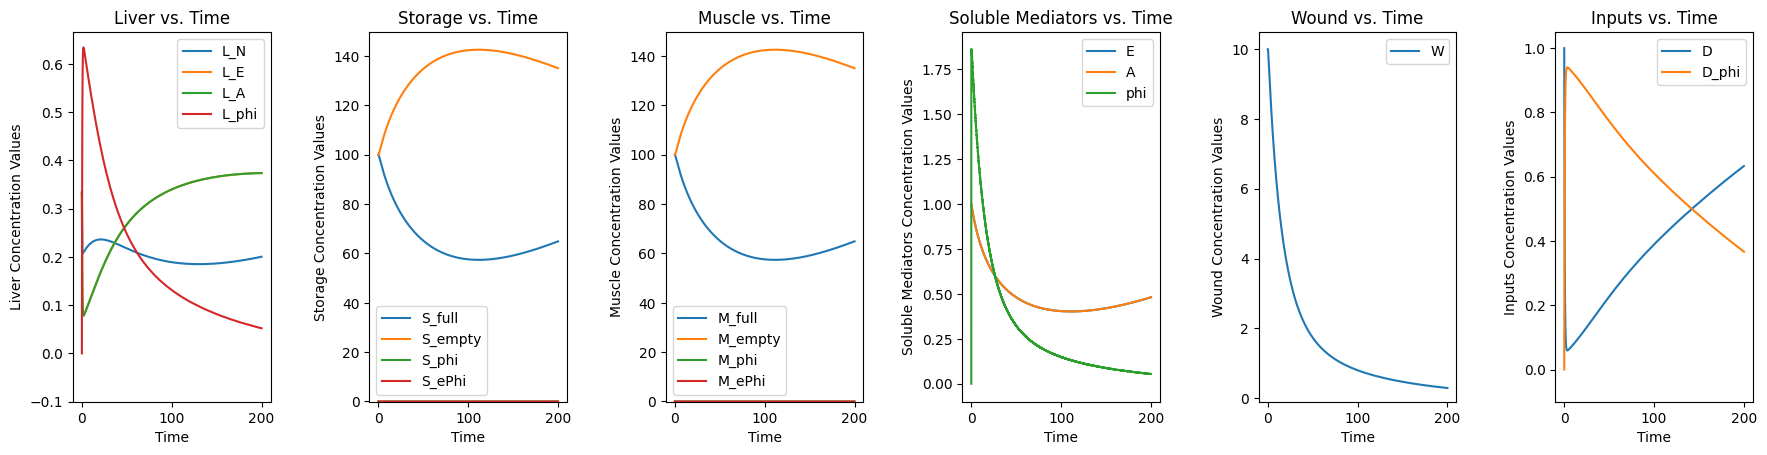

-0.24804730738587713
Final value of W: 0.2923703320261608


In [8]:
initWound = 10

diet = 1

woundValsVsTime = []

rxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

rxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

timeValuesList = []

weightValsVsTime = []
nutrientsVsTime = []

fractionIMW = 1.0

rxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#
rxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#
rxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#
rxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#
rxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#
rxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#
rxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#
rxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#
rxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

#
rxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

#
rxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#
rxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#
rxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#
rxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#
rxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#
rxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

#
rxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
rxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#
rxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#
rxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

#
rxnFlask.addReaction("Reaction 23: W -> W + phi", 75, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

#
rxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

#
rxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
rxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
rxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

#
rxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

#
rxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

#
rxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

#
rxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

#
rxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

#
rxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})



#
#This allows S_full to continue acting as an inflammation sink without changing state
#rxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 0, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
rxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi or S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1, 'S_phi' : 0})


#This allows S_empty to continue acting as an inflammation sink without changing state
#rxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 0, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
rxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi or S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1, 'S_ePhi' : 0})


#This allows M_full to continue acting as an inflammation sink while not changing state
#rxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 0, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
rxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi or M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1, 'M_phi' : 0})


#This allows M_empty to continue acting as an inflammation sink while not changing state
#rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 0, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
rxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi or M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1, 'M_ePhi' : 0})


reactionDerivative1 = rxnFlask.reactionDeriv(0, [initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

rxnFlask.runSystem(200)

rxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

timeValues = rxnFlask.latestSimulationOutput["t"]

localWeightDropValues = (46 * 2 - rxnFlask.latestSimulationOutput["y"][7] - rxnFlask.latestSimulationOutput["y"][11])

print(np.max(localWeightDropValues) / (46 * 2))

#print(rxnFlask.latestSimulationOutput["t"])

print(f"Final value of W: {rxnFlask.getFinalValueOfVariable('W')}")

rxnFlask.resetInitialCondition()

timeValuesList.append(timeValues)
woundValsVsTime.append(rxnFlask.latestSimulationOutput["y"][0])
weightValsVsTime.append(2 * rxnFlask.latestSimulationOutput["y"][7])
nutrientsVsTime.append(rxnFlask.latestSimulationOutput["y"][16])

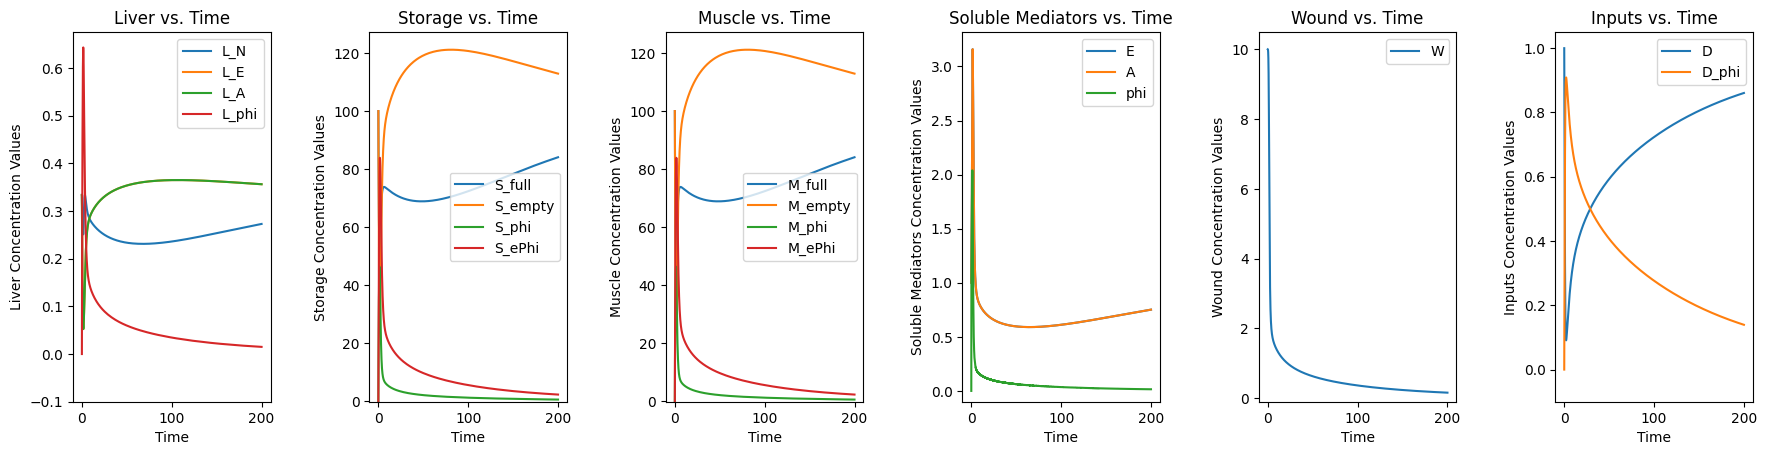

0.01060390846017287
Final value of W: 0.15946069960776446


In [9]:
initWound = 10

diet = 1

woundValsVsTime = []

brxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

brxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

timeValuesList = []

weightValsVsTime = []
nutrientsVsTime = []

fractionIMW = 1.0

brxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#
brxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#
brxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#
brxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#
brxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#
brxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#
brxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#
brxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#
brxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

#
brxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

#
brxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#
brxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#
brxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#
brxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#
brxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#
brxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

#
brxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
brxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#
brxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#
brxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

#
brxnFlask.addReaction("Reaction 23: W -> W + phi", 75, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

#
brxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

#
brxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
brxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
brxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

#
brxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

#
brxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

#
brxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

#
brxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

#
brxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

#
brxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})


brxnFlask.addReaction("Reaction 13a: S_full + g * phi -> S_full", 1, reactantsDict={'S_full' : 1, 'phi' : 1}, productsDict={'S_full' : 1})
#
brxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi or S_full", 1, reactantsDict={'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})

#rxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", (1 - fractionIMW), reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

brxnFlask.addReaction("Reaction 14a: S_empty + g * phi -> S_empty", 1, reactantsDict={'S_empty' : 1, 'phi' : 1}, productsDict={'S_empty' : 1})

brxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi or S_empty", 1, reactantsDict={'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
#rxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", (1 - fractionIMW), reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

brxnFlask.addReaction("Reaction 29a: M_full + g * phi -> M_full", 1, reactantsDict={'M_full' : 1, 'phi' : 1}, productsDict={'M_full' : 1})
#
brxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi or M_full", 1, reactantsDict={'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
#rxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , (1 - fractionIMW), reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

brxnFlask.addReaction("Reaction 30a: M_empty + g * phi -> M_empty", 1, reactantsDict={'M_empty' : 1, 'phi' : 1}, productsDict={'M_empty' : 1})

brxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi or M_empty", 1, reactantsDict={'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})


reactionDerivative2 = brxnFlask.reactionDeriv(0, [initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

brxnFlask.runSystem(200)

brxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

timeValues2 = brxnFlask.latestSimulationOutput["t"]

localWeightDropValues = (46 * 2 - brxnFlask.latestSimulationOutput["y"][7] - brxnFlask.latestSimulationOutput["y"][11])

print(np.max(localWeightDropValues) / (46 * 2))

#print(rxnFlask.latestSimulationOutput["t"])

print(f"Final value of W: {brxnFlask.getFinalValueOfVariable('W')}")

brxnFlask.resetInitialCondition()

woundValsVsTime.append(brxnFlask.latestSimulationOutput["y"][0])
weightValsVsTime.append(2 * brxnFlask.latestSimulationOutput["y"][7])
nutrientsVsTime.append(brxnFlask.latestSimulationOutput["y"][16])

In [ ]:
for k in range(len(reactionDerivative2)):
    print(f"{rxnFlask._entityList[k]} = {reactionDerivative2[k]}")

In [10]:
#1. Get boolean mask of finalWoundValues, <= 10% of initWound
def calculateWoundHealingTime(timeValues, woundValues, threshold):
  #initWound = woundValues[0], correct?
  healedWound = np.where(woundValues <= threshold * woundValues[0])[0]
  try:
    healedWoundIndex = healedWound[0]
  except(IndexError):
    #This ensures that, if the wound never was healed to the threshold, it
    #automatically reports the longest time
    return timeValues[-1]

  healedWoundTime = timeValues[healedWoundIndex]
  return healedWoundTime


In [12]:
calculateWoundHealingTime(timeValues2, woundValsVsTime[0], 0.1)

np.float64(21.97239071343241)